# **🌿 Plant Disease Detection & Recovery System -  Training Research**

**Developer:** **Tedros Nigus**

**Objective:** **Training a CNN model to support Ethiopian agriculture.**

## Importing Libraries

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

**Creating the Kaggle JSON**

In [4]:
import os


!mkdir -p ~/.kaggle

os.environ['KAGGLE_USERNAME'] = "teddynigus"
os.environ['KAGGLE_KEY'] = "KGAT_9fce4462ee37b665bac352e05b2eae05"

import json
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump({'username': os.environ['KAGGLE_USERNAME'], 'key': os.environ['KAGGLE_KEY']}, f)

!chmod 600 ~/.kaggle/kaggle.json

**Downloading the Dataset** (Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset)

In [5]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
new-plant-diseases-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


**Unzipping & Moving the Data**

In [7]:
!unzip -qo new-plant-diseases-dataset.zip

In [8]:
# This moves the folders
!mv "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train" "train"
!mv "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid" "valid"

# **Data Preprocessing**

### **Training Image Preprocessing**

In [12]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


## **Validation Image Preprocessing**

In [13]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [14]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [15]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[ 70.75  63.75  70.75]
   [ 72.25  65.25  72.25]
   [ 76.5   69.5   76.5 ]
   ...
   [ 91.5  110.75  78.25]
   [ 64.75  94.75  58.75]
   [ 68.75 105.75  69.25]]

  [[ 76.5   69.5   76.5 ]
   [ 73.25  66.25  73.25]
   [ 75.    68.    75.  ]
   ...
   [ 81.    96.    65.  ]
   [ 63.75  89.    54.5 ]
   [ 55.75  88.75  51.75]]

  [[ 73.75  66.75  73.75]
   [ 69.5   62.5   69.5 ]
   [ 70.5   63.5   70.5 ]
   ...
   [ 78.75  89.25  57.5 ]
   [ 67.5   87.25  52.  ]
   [ 56.25  81.5   44.  ]]

  ...

  [[110.75 101.75 106.75]
   [105.    96.   101.  ]
   [109.   100.   105.  ]
   ...
   [ 69.25  57.25  61.25]
   [ 60.    48.    52.  ]
   [ 59.75  47.75  51.75]]

  [[113.5  104.5  109.5 ]
   [108.25  99.25 104.25]
   [114.   105.   110.  ]
   ...
   [ 45.    33.    37.  ]
   [ 37.75  25.75  29.75]
   [ 35.25  23.25  27.25]]

  [[103.75  94.75  99.75]
   [107.25  98.25 103.25]
   [122.   113.   118.  ]
   ...
   [ 31.25  19.25  23.25]
   [ 26.75  14.75  18.75]
   [ 20.25   8.25  1

# **Visualizing the images**

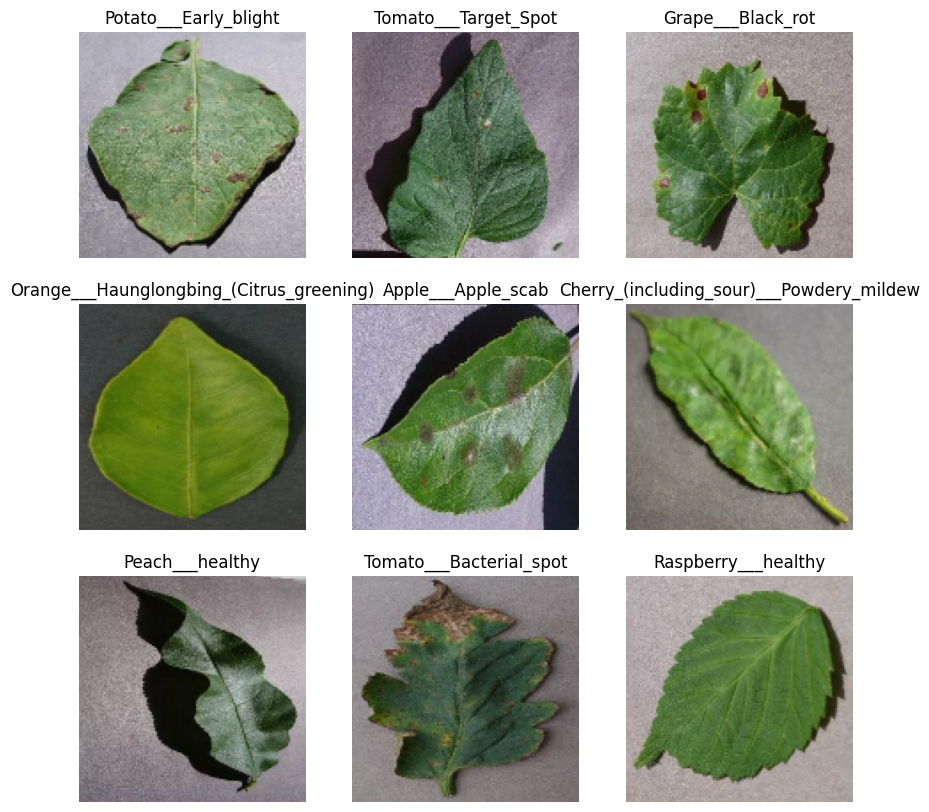

In [20]:
plt.figure(figsize=(10, 10))
for images, labels in training_set.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        # USE np.argmax here to get the correct index
        result_index = np.argmax(labels[i])
        plt.title(training_set.class_names[result_index])

        plt.axis("off")

### **To avoid Overshooting**
1. Choose small learning rate default 0.001 we are taking 0.0001
2. There may be chance of Underfitting, so increase number of neuron
3. Add more Convolution layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

# **Building Model**

In [21]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [22]:
model = Sequential()

In [23]:
## Building Convolution Layer

In [24]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [26]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [27]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [28]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [29]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [30]:
model.add(Flatten())

In [31]:
model.add(Dense(units=1500,activation='relu'))

In [32]:
model.add(Dropout(0.4))

In [33]:
#Output Layer
model.add(Dense(units=38,activation='softmax'))

### **Compiling Model**

In [38]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

### **Model Training**

In [40]:
history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=10
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 176s 72ms/step - accuracy: 0.5983 - loss: 1.3584 - val_accuracy: 0.8385 - val_loss: 0.5189
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 145s 66ms/step - accuracy: 0.8550 - loss: 0.4623 - val_accuracy: 0.9082 - val_loss: 0.2872
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 198s 64ms/step - accuracy: 0.9104 - loss: 0.2765 - val_accuracy: 0.9241 - val_loss: 0.2381
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 149s 68ms/step - accuracy: 0.9390 - loss: 0.1868 - val_accuracy: 0.9099 - val_loss: 0.2814
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.9548 - loss: 0.1385 - val_accuracy: 0.9384 - val_loss: 0.1874
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.9639 - loss: 0.1084 - val_accuracy: 0.9300 - val_loss: 0.2350
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.9704 - loss: 0.0901 - val_accuracy: 0.9558 - val_loss: 0.1509
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 148s 67ms/step - accuracy: 

## **Model Evaluation**

In [41]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.9893 - loss: 0.0316


In [42]:
print(train_loss,train_acc)

0.03158048167824745 0.9893306493759155


In [43]:
#Model on Validation set
val_loss,val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.9602 - loss: 0.1368


In [44]:
print(val_loss,val_acc)

0.13680499792099 0.9602208137512207


### **Saving Model**

In [46]:
model.save("ethio_plant_disease_model.h5")

In [49]:
history.history

{'accuracy': [0.5983355641365051,
  0.8549683690071106,
  0.9103919267654419,
  0.9389572739601135,
  0.9548332095146179,
  0.9638950228691101,
  0.9703961610794067,
  0.9752329587936401,
  0.9767835736274719,
  0.9825876951217651],
 'loss': [1.3583874702453613,
  0.4623364806175232,
  0.276454359292984,
  0.18677860498428345,
  0.13847854733467102,
  0.10844466835260391,
  0.0901329442858696,
  0.07536449283361435,
  0.06989781558513641,
  0.05583948642015457],
 'val_accuracy': [0.8385499715805054,
  0.9082062244415283,
  0.9241406917572021,
  0.9099134802818298,
  0.9384247660636902,
  0.9300022721290588,
  0.9558388590812683,
  0.957659900188446,
  0.9683587551116943,
  0.9602208137512207],
 'val_loss': [0.518923819065094,
  0.2872007489204407,
  0.2381012737751007,
  0.28138619661331177,
  0.1873634159564972,
  0.23497729003429413,
  0.1508861929178238,
  0.13729232549667358,
  0.10962230712175369,
  0.13680499792099]}

In [50]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(history.history,f)

In [51]:
history.history['val_accuracy']

[0.8385499715805054,
 0.9082062244415283,
 0.9241406917572021,
 0.9099134802818298,
 0.9384247660636902,
 0.9300022721290588,
 0.9558388590812683,
 0.957659900188446,
 0.9683587551116943,
 0.9602208137512207]

### **Accuracy Visualization**

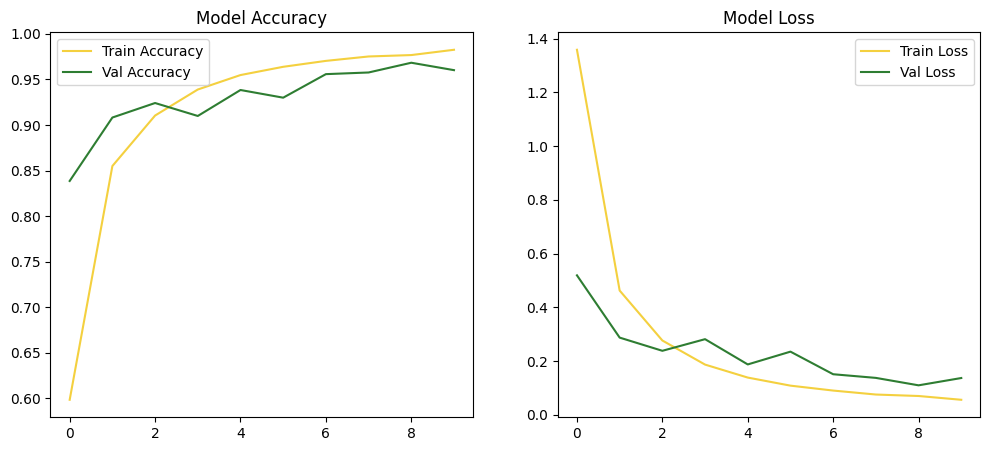

In [45]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#F4D03F')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#2E7D32')
plt.title('Model Accuracy')
plt.legend()

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#F4D03F')
plt.plot(history.history['val_loss'], label='Val Loss', color='#2E7D32')
plt.title('Model Loss')
plt.legend()

plt.show()

### **Other metrics for model evaluation**

In [52]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [53]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [54]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step


(array([[9.99999404e-01, 2.95685226e-07, 1.02474196e-10, ...,
         2.33770726e-14, 7.18760920e-14, 1.52461583e-12],
        [9.99686778e-01, 1.17499265e-04, 5.36774465e-08, ...,
         9.85835892e-12, 9.34992014e-12, 7.47232221e-10],
        [1.00000000e+00, 1.88660110e-08, 1.40518785e-09, ...,
         1.22105834e-16, 3.49449473e-14, 1.20051690e-12],
        ...,
        [4.25504254e-08, 3.11765302e-09, 1.53577574e-07, ...,
         2.05114645e-08, 5.48678720e-08, 9.99883771e-01],
        [3.53096652e-07, 6.04393824e-09, 2.22106692e-07, ...,
         2.05854889e-08, 7.78381803e-08, 9.99972820e-01],
        [1.42485860e-15, 7.55458561e-17, 1.89237515e-15, ...,
         3.98771821e-18, 6.83206526e-15, 1.00000000e+00]], dtype=float32),
 (17572, 38))

In [55]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [56]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [57]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [58]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [60]:
from sklearn.metrics import classification_report,confusion_matrix

In [61]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.88      0.93       504
                                 Apple___Black_rot       0.96      1.00      0.98       497
                          Apple___Cedar_apple_rust       0.97      0.98      0.98       440
                                   Apple___healthy       0.88      0.99      0.93       502
                               Blueberry___healthy       0.97      0.95      0.96       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.99      0.99       421
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.88      0.94      0.91       410
                       Corn_(maize)___Common_rust_       0.97      1.00      0.98       477
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.90      0.

In [62]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[446,  14,   0, ...,   0,   0,   0],
       [  0, 495,   0, ...,   0,   0,   0],
       [  0,   0, 432, ...,   0,   0,   1],
       ...,
       [  0,   0,   0, ..., 481,   1,   0],
       [  0,   0,   0, ...,   0, 444,   2],
       [  0,   0,   1, ...,   0,   0, 478]])

### **Confusion Matrix Visualization**

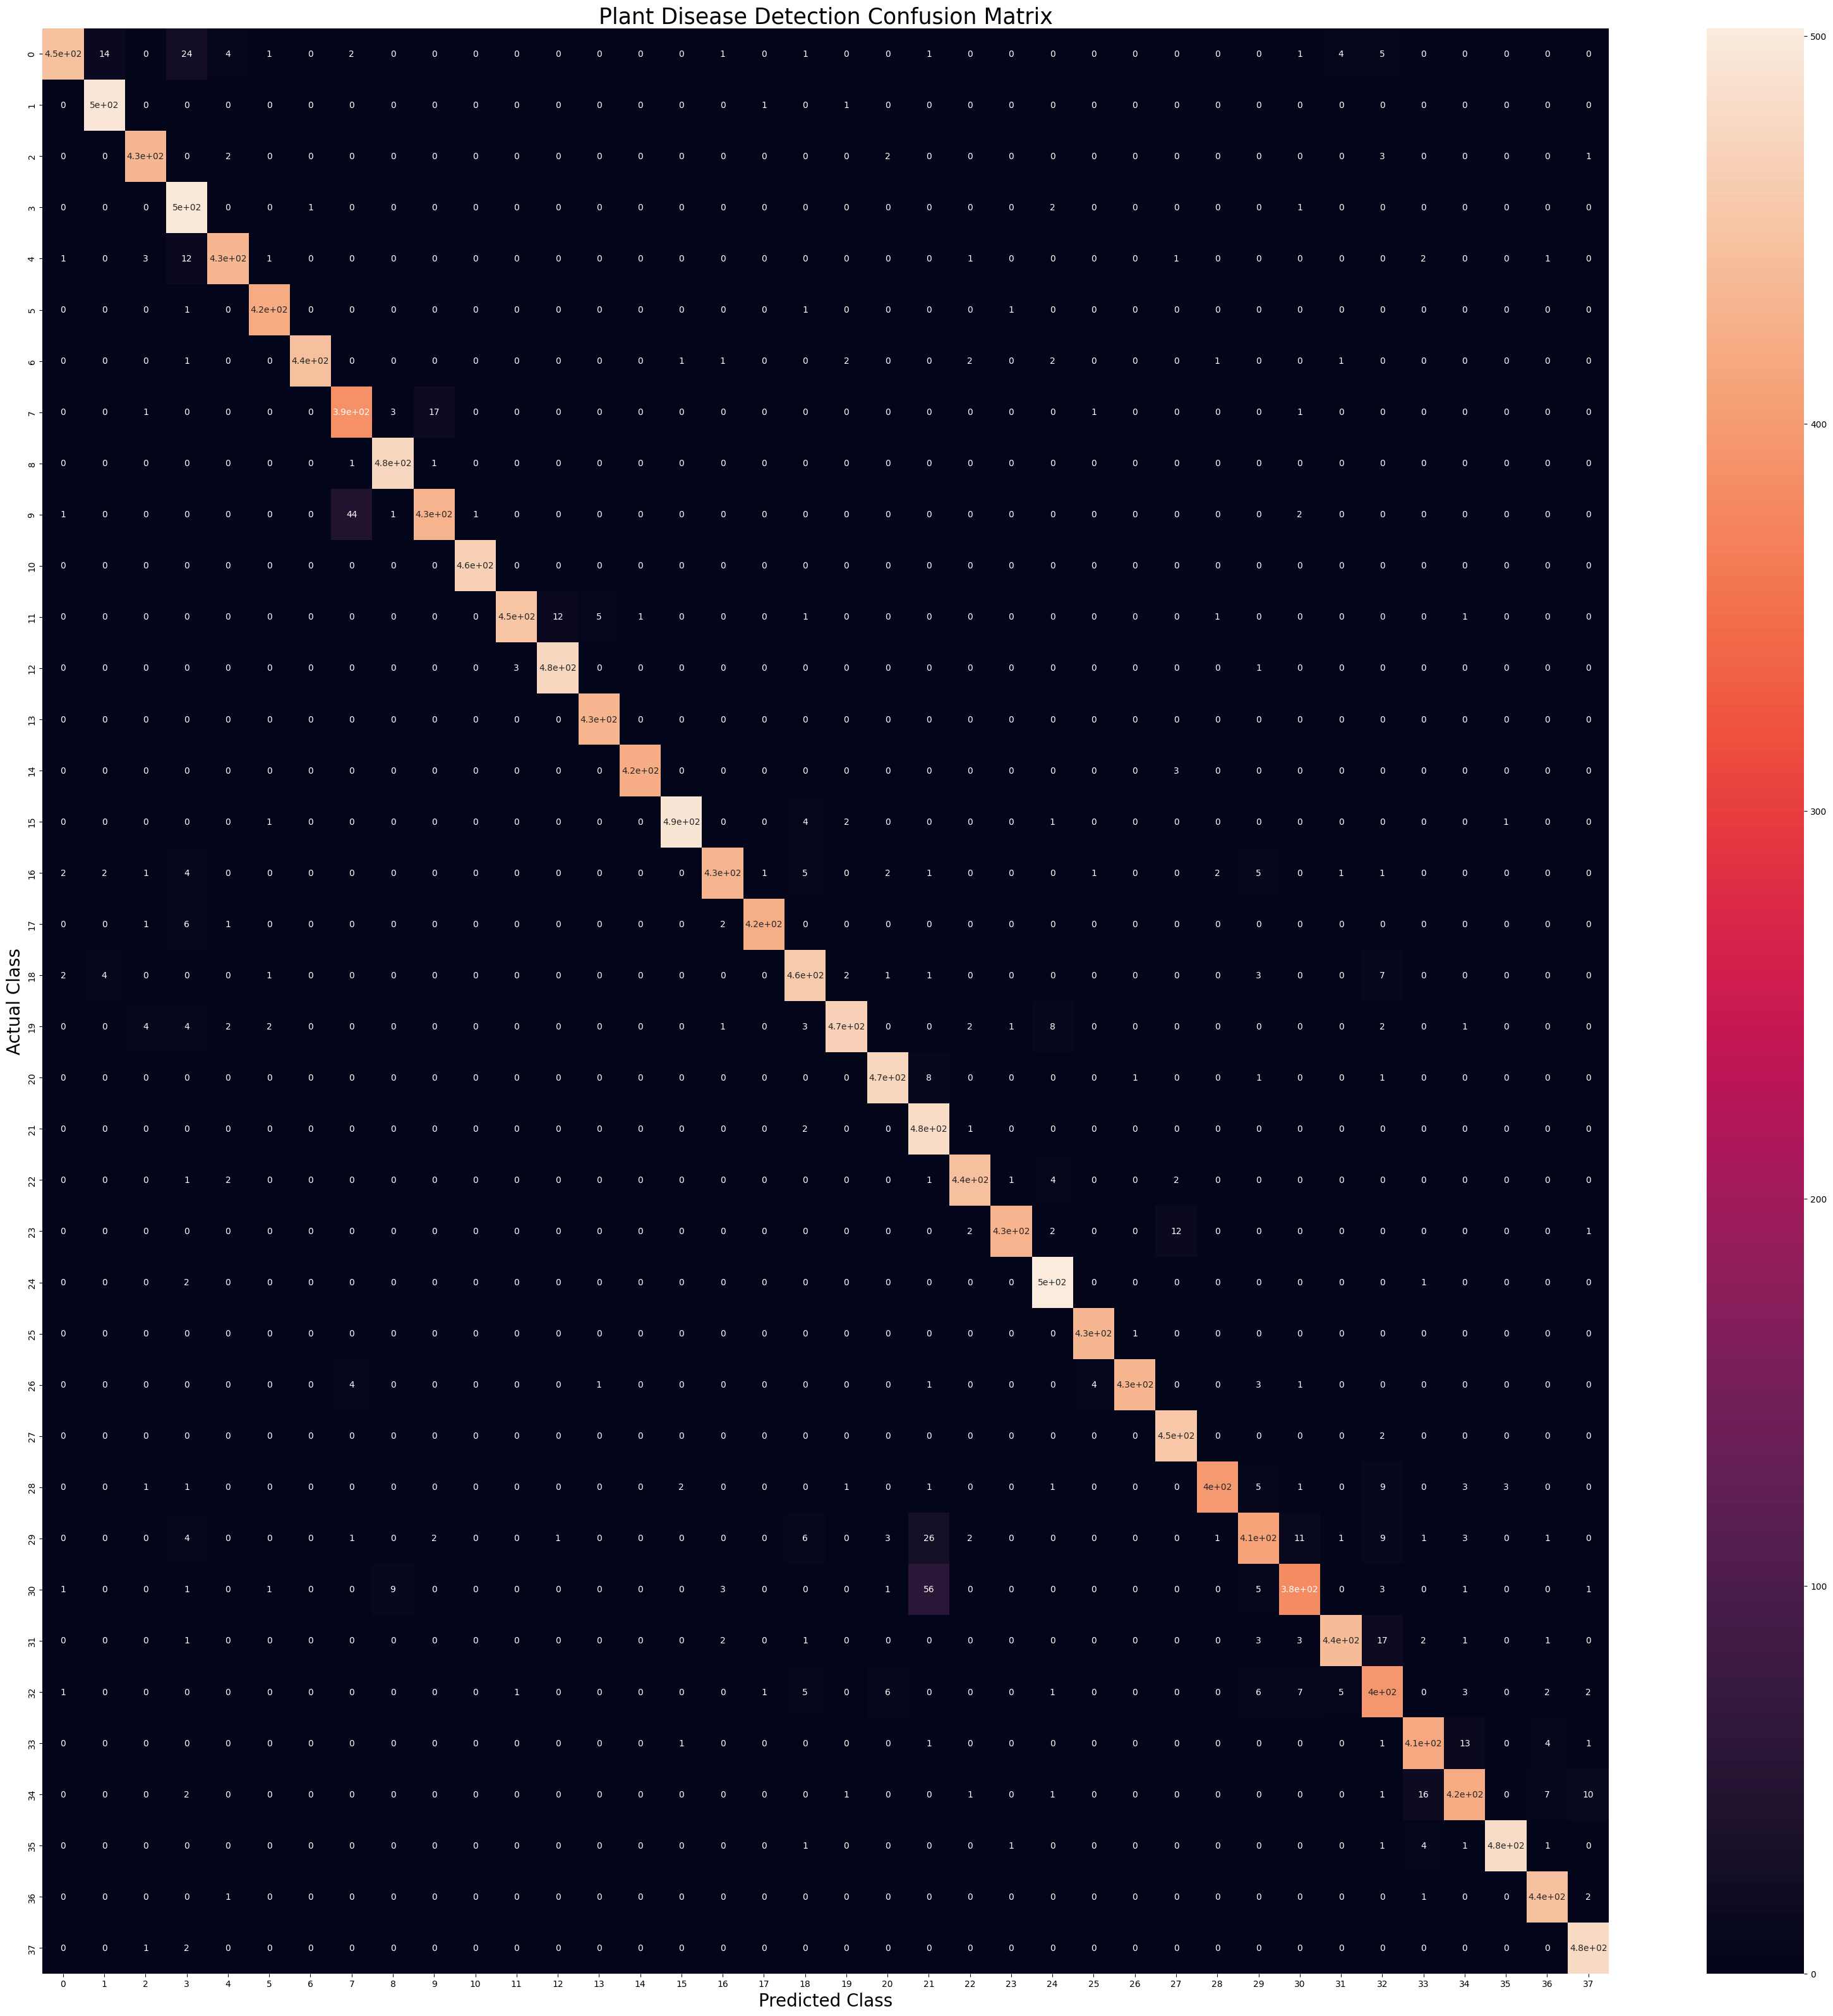

In [64]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Detection Confusion Matrix",fontsize=25)
plt.show()